# MODELO DE SUSCEPTIBILIDAD A INUNDACIONES UTILIZANDO APRENDIZAJE AUTOMATICO Y DATOS DE GEE


Autor: Sebastian Velosa Bohorquez

Curso: Percepción Remota

Herramientas: Google Earth Engine + RF

---
# 1. Introducción

El presente estudio tiene como objetivo desarrollar un modelo de susceptibilidad a inundaciones mediante técnicas de aprendizaje automático, integrando información derivada de sensores remotos y variables geoespaciales. El área de estudio corresponde a la Subcuenca Hidrográfica del Bajo Sinú, una región caracterizada por su alta dinámica hidrológica y recurrentes eventos de inundación estacional.

Para la construcción del modelo, se integran múltiples fuentes de información geoespacial organizadas en tres grupos principales: (i) variables geomorfológicas derivadas de modelos digitales de elevación, incluyendo elevación, pendiente, curvatura y altura sobre el drenaje más cercano; (ii) variables hidrológicas derivadas del producto MERIT Hydro y análisis de redes de drenaje, tales como acumulación de flujo y distancia a ríos; y (iii) variables ambientales y antrópicas obtenidas a partir de imágenes satelitales Sentinel-2, productos globales de cobertura terrestre y datasets de infraestructura urbana.

El inventario de inundaciones fue generado a partir de imágenes Sentinel-1, utilizando un enfoque basado en la diferencia de retrodispersión antes y después del evento, complementado con la técnica de umbralización automática de Otsu y la eliminación de cuerpos de agua permanentes mediante el Global Surface Water dataset. Este inventario constituye la variable objetivo del modelo (clase inundado / no inundado).

A partir de estos insumos, se construye una base de datos espacial de puntos de entrenamiento, la cual es utilizada para entrenar un modelo de clasificación supervisada basado en Random Forest. El desempeño del modelo se evalúa mediante métricas estándar como exactitud global, matriz de confusión, curva ROC y el área bajo la curva (AUC), permitiendo cuantificar la capacidad predictiva del modelo.

---
#2. FLUJO DE TRABAJO

In [2]:
import pandas as pd
import numpy as np
import json

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    auc,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# 3. PREPROCESAMIENTO DE DATOS

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Asset05_AllSamples.csv to Asset05_AllSamples.csv


In [4]:
df = pd.read_csv("Asset05_AllSamples.csv")

df.head()

,system:index,BuiltUp,Curvature,DistRiver,Elevation,Flood,FlowAccum,HAND,LandCover,NDVI,NDWI,Slope,random,.geo
0,0,13.149684,1.310745,3.755876e+03,25.598917,0,0.012567,10.177879,30.0,0.520460,-0.547497,1.689509,0.357032,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,13.315194,-0.808748,1.897367e+02,14.691923,0,0.009304,1.870944,30.0,0.621445,-0.584358,0.947346,0.375799,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,0.000000,22.938599,6.855837e+03,92.570210,0,0.008453,25.550755,30.0,0.688583,-0.661164,13.054238,0.388908,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,0.000000,-8.064232,2.700000e+02,32.838337,0,0.013641,2.722030,30.0,0.660310,-0.623167,3.715998,0.485591,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,0.000000,-3.753613,1.390228e+06,36.250538,0,0.085103,0.352568,30.0,0.348674,-0.436784,2.992882,0.319764,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [5]:
df = df.dropna()

df['Flood'] = df['Flood'].astype(int)

## Visualización espacial

In [6]:
def get_coords(geo):
    geom = json.loads(geo)
    coords = geom["coordinates"]
    return coords[0], coords[1]

df["lon"], df["lat"] = zip(*df[".geo"].apply(get_coords))

In [7]:
flooded = df[df["Flood"] == 1]
non_flooded = df[df["Flood"] == 0]

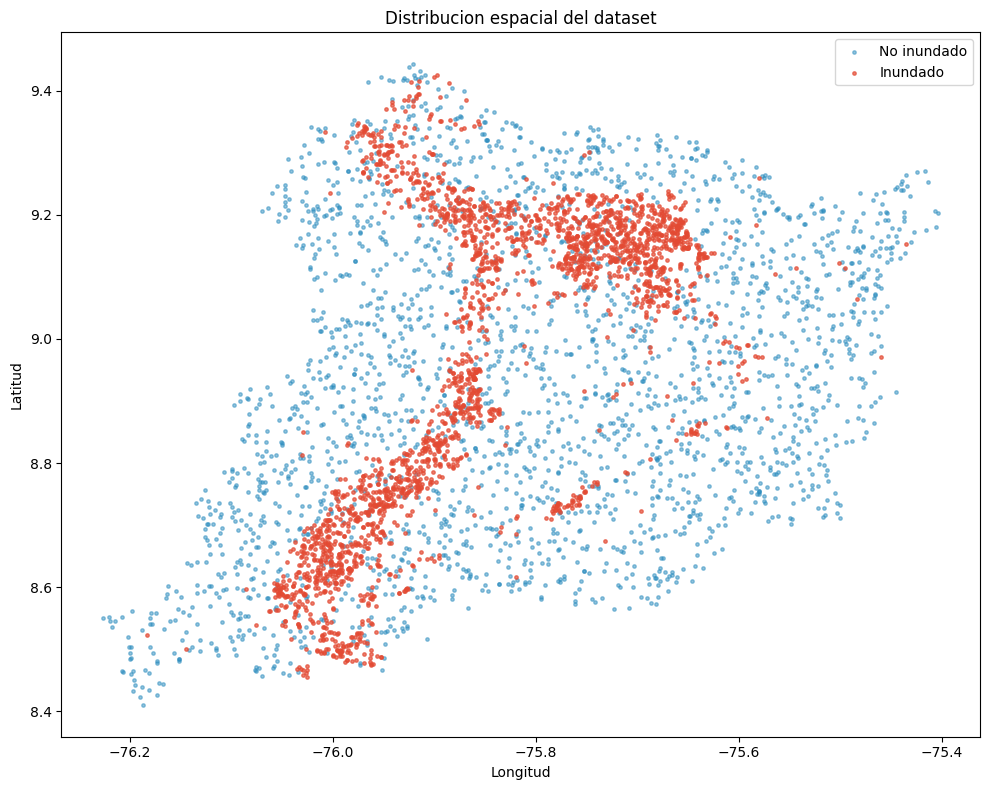

In [8]:
plt.figure(figsize=(10,8))

plt.scatter(non_flooded["lon"], non_flooded["lat"],
            s=6, c="#2b8cbe", alpha=0.5, label="No inundado")

plt.scatter(flooded["lon"], flooded["lat"],
            s=6, c="#e34a33", alpha=0.7, label="Inundado")

plt.title("Distribucion espacial del dataset")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.tight_layout()

plt.show()

In [9]:
print("\nResumen estadístico:")
df.describe()


Resumen estadístico:


,system:index,BuiltUp,Curvature,DistRiver,Elevation,Flood,FlowAccum,HAND,LandCover,NDVI,NDWI,Slope,random,lon,lat
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,18.378494,0.221420,1.864586e+05,27.360993,0.50000,47.245467,5.036413,39.245000,0.534347,-0.514714,2.255270,0.498186,-75.827501,8.950327
std,1443.520003,174.496729,4.769105,4.698953e+05,37.148164,0.50005,463.905930,12.716559,23.075777,0.183983,0.168346,3.785264,0.286256,0.161602,0.243235
min,0.000000,0.000000,-42.230896,0.000000e+00,0.000000,0.00000,0.008435,0.000000,10.000000,-0.438597,-0.841215,0.000000,0.000136,-76.226436,8.410655
25%,1249.750000,0.000000,-0.411095,9.003749e+02,4.500000,0.00000,0.011594,0.387065,30.000000,0.456282,-0.602544,0.213378,0.250566,-75.956995,8.739757
50%,2499.500000,0.000000,0.147065,2.549382e+03,13.595854,0.50000,0.027630,0.974623,30.000000,0.559218,-0.551819,0.673468,0.499645,-75.850442,8.968602
75%,3749.250000,0.000000,1.191657,6.820565e+03,31.038317,1.00000,0.205224,3.219196,30.000000,0.653116,-0.488493,2.578323,0.743343,-75.705043,9.165032
max,4999.000000,4257.502400,47.851486,1.390228e+06,359.885130,1.00000,12632.037000,245.683530,95.000000,0.940599,0.510204,38.732983,0.999928,-75.403676,9.442385


In [10]:
print("\nInformación general:")
df.info()


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  5000 non-null   int64  
 1   BuiltUp       5000 non-null   float64
 2   Curvature     5000 non-null   float64
 3   DistRiver     5000 non-null   float64
 4   Elevation     5000 non-null   float64
 5   Flood         5000 non-null   int64  
 6   FlowAccum     5000 non-null   float64
 7   HAND          5000 non-null   float64
 8   LandCover     5000 non-null   float64
 9   NDVI          5000 non-null   float64
 10  NDWI          5000 non-null   float64
 11  Slope         5000 non-null   float64
 12  random        5000 non-null   float64
 13  .geo          5000 non-null   object 
 14  lon           5000 non-null   float64
 15  lat           5000 non-null   float64
dtypes: float64(13), int64(2), object(1)
memory usage: 625.1+ KB


# Analisis de variables



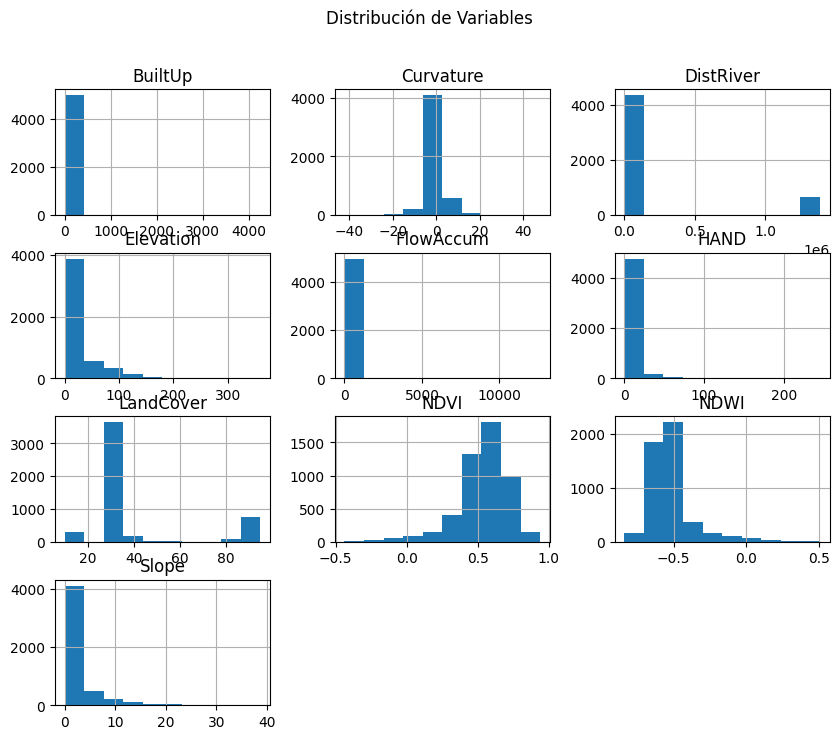

In [11]:
# Histogramas de variables

df[[
    'BuiltUp', 'Curvature', 'DistRiver', 'Elevation', 'FlowAccum', 'HAND',
       'LandCover', 'NDVI', 'NDWI', 'Slope'
]].hist(figsize=(10,8))

plt.suptitle("Distribución de Variables")
plt.show()

# 7. Preparación de variables para el modelo

In [12]:
# Variable objetivo
y = df["Flood"]

# Variables predictoras (quita columnas no útiles)
X = df.drop(columns=["Flood", "system:index", ".geo","random"])

X = X.fillna(X.mean())

print(X.columns)

Index(['BuiltUp', 'Curvature', 'DistRiver', 'Elevation', 'FlowAccum', 'HAND',
       'LandCover', 'NDVI', 'NDWI', 'Slope', 'lon', 'lat'],
      dtype='object')


7.2 Separación datos de entrenamiento/prueba

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 8. Modelo RANDOM FOREST

In [14]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

## 8.2 Predicción

In [15]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

Matriz de confusion

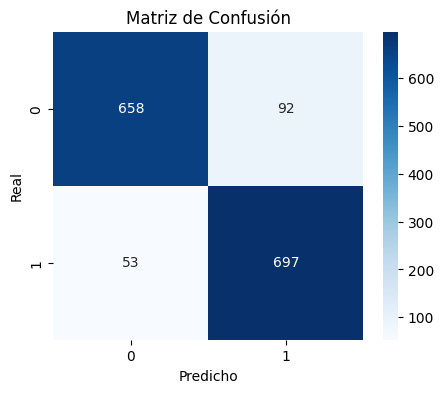

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

Evaluación del Modelo

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9033333333333333
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       750
           1       0.88      0.93      0.91       750

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



ROC + AUC

AUC: 0.9598666666666666


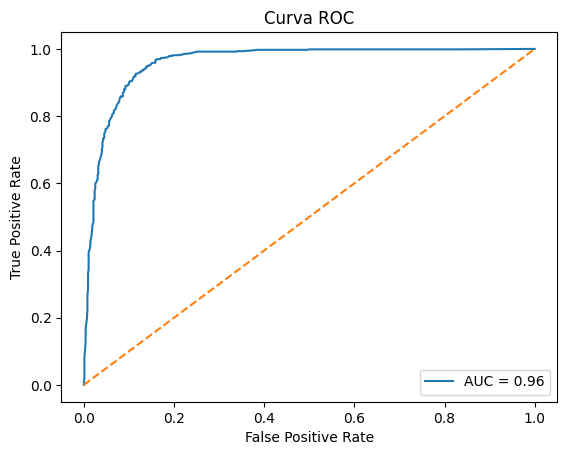

In [25]:
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = " + str(round(auc,3)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [26]:
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2_rf = r2_score(
    y_test,
    y_pred
)
print("\nMÉTRICAS")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.3f}")


MÉTRICAS
RMSE: 0.31
R²: 0.613


IMPORTANCIA DE VARIABLES




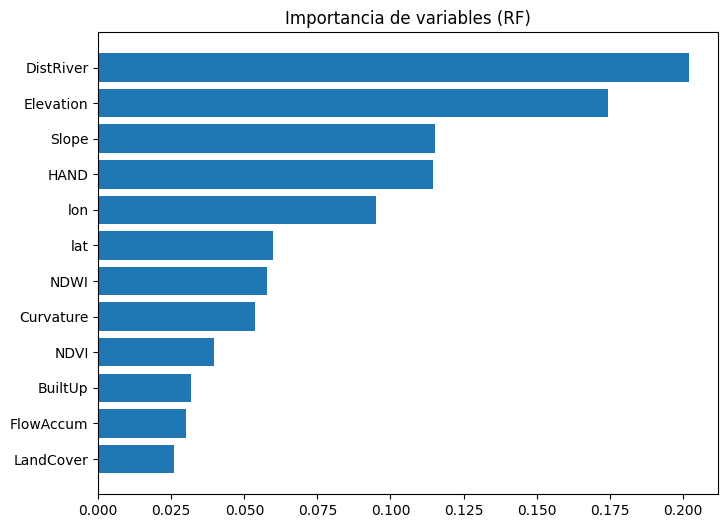

In [21]:
import numpy as np

importances = rf.feature_importances_
features = X.columns

idx = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(features[idx], importances[idx])
plt.title("Importancia de variables (RF)")
plt.show()

In [ ]:
!pip install shap
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

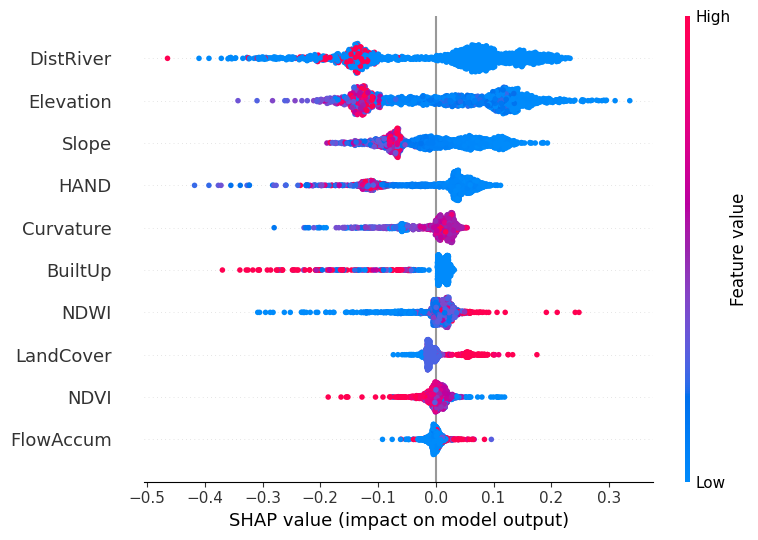

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test)

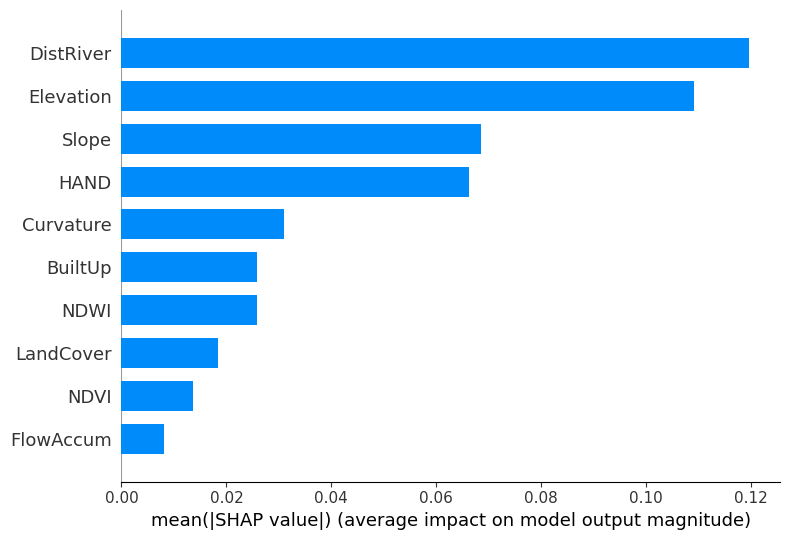

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

MAPA DE SUSCEPTIBILIDAD

In [ ]:
df["susceptibility"] = rf.predict_proba(X)[:,1]

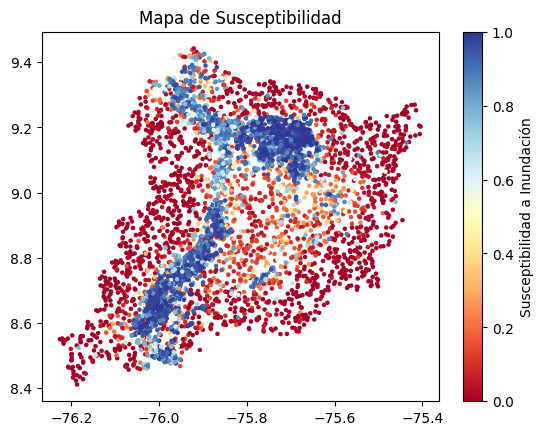

In [ ]:
import matplotlib.pyplot as plt
import json

def get_coords(geo):
    geom = json.loads(geo)
    coords = geom["coordinates"]
    return coords[0], coords[1]

# Re-extract 'lon' and 'lat' to ensure they are present if df was reset
if 'lon' not in df.columns or 'lat' not in df.columns:
    df["lon"], df["lat"] = zip(*df[".geo"].apply(get_coords))

plt.scatter(df['lon'], df['lat'],
            c=df['susceptibility'],
            cmap='RdYlBu',
            s=5)

plt.colorbar(label='Susceptibilidad a Inundación')
plt.title('Mapa de Susceptibilidad')
plt.show()

#Guardar el modelo

In [23]:
import joblib

joblib.dump(
    rf,
    "random_forest_flood.pkl"
)

['random_forest_flood.pkl']

In [24]:
from google.colab import files

files.download(
    "random_forest_flood.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>